# Linear Discriminant Analysis in Machine Learning
**Last Updated : 13 Sep, 2025**

Linear Discriminant Analysis (LDA) also known as Normal Discriminant Analysis is a supervised classification method that helps separate two or more classes by converting a higher-dimensional feature space into a lower-dimensional space. It does this by finding a **linear combination of features** that best separates classes within a dataset.

## Overlapping
For example, imagine we have two classes that need to be separated efficiently. Each class may have multiple features, and using only a single feature to classify them may result in **overlap**. LDA solves this by using multiple features together, improving class separation and classification accuracy.

LDA works under a few assumptions. Understanding them helps explain **why LDA gives a straight-line (linear) boundary**.

## Key Assumptions of LDA
For LDA to perform effectively, certain assumptions are made:

- **Gaussian Distribution:** The data in each class should follow a normal bell-shaped distribution.
- **Equal Covariance Matrices:** All classes should have the same covariance structure.
- **Linear Separability:** The data should be separable using a straight line or plane.

## Why do we need “Equal Covariance Matrices”?
Think of each class as a “cloud” of points.
- The **covariance matrix** describes the cloud’s **shape and orientation**: how spread out it is in each direction and how features move together (correlation).

If **all classes have the same covariance**, then their clouds have the **same shape** (same ellipse/ellipsoid shape), just centered in different places. In that case, the best separating boundary between them becomes a **straight line / plane**, which is exactly what LDA is designed to find.

If classes have **different covariances** (different shapes), then one class might be narrow in one direction while the other is wide or tilted differently. The best separation boundary typically becomes **curved** (quadratic). That situation is better modeled by **QDA (Quadratic Discriminant Analysis)** rather than LDA.

Practical benefit: assuming equal covariance lets LDA estimate **one pooled covariance matrix** using data from all classes, which is often more stable (especially with limited data).

## Extensions to LDA

**Quadratic Discriminant Analysis (QDA):** Each class uses its own estimate of variance (or covariance) allowing it to handle more complex relationships.

**Flexible Discriminant Analysis (FDA):** Uses non-linear combinations of inputs such as splines to handle non-linear separability.

**Regularized Discriminant Analysis (RDA):** Introduces regularization into the covariance estimate to prevent overfitting.

## Implementation of LDA using Python

We will perform linear discriminant analysis using Scikit-learn library on the Iris dataset.

### 1. Importing Required Libraries

We import all necessary libraries for data processing, visualization, dimensionality reduction, and modeling:

- **NumPy:** for numerical operations and array manipulations
- **Pandas:** for creating and managing structured datasets
- **Matplotlib.pyplot:** for plotting and visualizations
- **Scikit-learn:** for machine learning tools like dataset loading, preprocessing, dimensionality reduction, and classifiers

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

In [2]:
print(load_iris().data[:10])
print(load_iris().target[:1000])
print(load_iris().target_names)
print(load_iris().feature_names)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


## 2. Loading the Iris Dataset

`load_iris()` is a function that loads the iris dataset and returns a Bunch object, which is similar to a dictionary. The Bunch object contains several attributes, including:
- **`data`:** The feature matrix containing measurements
- **`target`:** The target labels (class indices)
- **`target_names`:** Names of the classes (species)
- **`DESCR`:** A detailed description of the dataset
- **`feature_names`:** Names of the features (measurements)


#### Converting into a Pandas DataFrame
We load the Iris dataset and convert it into a Pandas DataFrame. Features `X` and target labels `y` are separated:

- `pd.DataFrame(columns=..., data=...)` creates a DataFrame from raw data
- `iloc[:, 0:4]` selects first four columns as features
- `iloc[:, 4]` selects the target column

In [3]:
iris = load_iris()
dataset = pd.DataFrame(data=iris.data, columns=iris.feature_names)
dataset['target'] = iris.target

print(dataset.head(), '\n---')

X = dataset.iloc[:, 0:4].values
Y = dataset.iloc[:, 4].values

print(X[:5], '\n---')
print(Y[40:70])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0   
---
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]] 
---
[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


#### Understanding iloc and .values

**`iloc[:, 0:4].values`**
- `iloc[:, 0:4]` selects **all rows** (`:`) and **columns 0 through 3** (`0:4` is exclusive of 4)
- `.values` converts the DataFrame selection into a **NumPy array**
- Result: A 2D array containing only the feature columns (sepal length, sepal width, petal length, petal width)

**`iloc[:, 4].values`**
- `iloc[:, 4]` selects **all rows** (`:`) and **column 4** (the target column)
- `.values` converts the Series into a **NumPy array**
- Result: A 1D array containing the class labels (0, 1, 2 for the three iris species)

### 3. Data Preprocessing

We scale the features and encode the target labels, then split the dataset into training and testing sets:

- `StandardScaler().fit_transform(X)` scales features to have mean=0 and standard deviation=1
- `LabelEncoder().fit_transform(y)` encodes categorical labels as integers
- `train_test_split(X, y, test_size=0.2, random_state=42)` splits data into 80% train and 20% test

In [4]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)

print(X_scaled[:5], "\n---\n", Y_encoded[:10])

X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y_encoded, test_size=0.2, random_state=42)

[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]] 
---
 [0 0 0 0 0 0 0 0 0 0]


#### Understanding Key Preprocessing Functions

**LabelEncoder**
- Converts categorical text labels (like "setosa", "versicolor") into integers (0, 1, 2)
- Machine learning models need numeric input, so this makes text labels usable
- In the Iris dataset, the labels are already numeric, but encoding ensures consistent format

**train_test_split**
- Splits your data into two parts: training set (to teach the model) and testing set (to evaluate it)
- `test_size=0.2` means 20% of data goes to testing, 80% to training
- This prevents overfitting by testing on unseen data

**random_state=42**
- A seed number that controls the random splitting
- Using the same number (like 42) ensures you get the **same split every time** you run the code
- This makes results reproducible and comparable across different runs

### <br>4. Visualizing the Original Iris Dataset in 3D

We create a 3D scatter plot using the first three features to visualize the original data distribution:

- **Axes3D** enables 3D plotting in matplotlib
- `scatter(..., c=y, cmap='rainbow', alpha=0.7, edgecolors='b')` colors points by class with transparency and blue edges

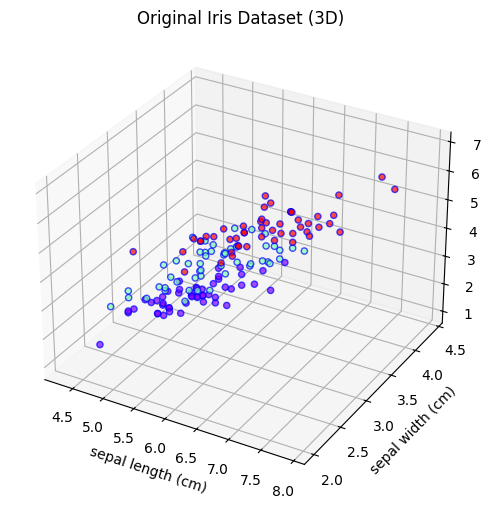

In [5]:
fig = plt.figure(figsize=(12, 6))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=Y_encoded, cmap='rainbow', alpha=0.7, edgecolors='b')

ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.set_title('Original Iris Dataset (3D)')

plt.show()

#### Understanding the 3D Plot Parameters

**`add_subplot(111)`**
- The three digits `111` mean: `1` row, `1` column, position `1`
- It creates a single plot that fills the entire figure
- If you wanted 2 plots side-by-side, you'd use `121` (1 row, 2 columns, position 1) and `122` (position 2)

**Scatter plot parameters:**
- **`X[:,0], X[:,1], X[:,2]`** - selects the first three feature columns as x, y, and z coordinates
- **`c=Y_encoded`** - colors each point based on its class label (0, 1, or 2)
- **`cmap='rainbow'`** - uses a rainbow color scheme to differentiate classes
- **`alpha=0.7`** - sets transparency to 70% so overlapping points are visible
- **`edgecolors='b'`** - adds blue edges around each point for better visibility

### <br>5. Random Forest Decision Boundary Without LDA

We train a Random Forest on the original features (first two features only for visualization) and plot the decision boundary:

- **`RandomForestClassifier(max_depth=2, random_state=0)`** initializes the classifier with limited depth
- **`.fit(X_train_2D, y_train)`** trains the classifier on 2D training data
- **`.predict()`** predicts class labels over a grid to visualize the decision boundary
- **`contourf()`** fills the decision regions with colors, showing how the model separates classes

#### Idea-level explanation of the decision boundary code

- **Pick 2 features for visualization:** `X_train_2D = X_train[:, :2]` keeps only the first two feature columns so we can draw a 2D plot. (The model could use more features, but then we can’t visualize the boundary on a flat 2D chart.)

- **Train a model on those 2 features:** We create a `RandomForestClassifier` and fit it on `(X_train_2D, Y_train)`. Now the model can predict a class (0/1/2) from 2D input.

- **Create a grid of points covering the plot area:**
  - `x_min/x_max` and `y_min/y_max` define the plot limits (with a little margin).
  - `np.meshgrid(...)` creates many coordinate pairs `(x, y)` across that area.

- **Predict a class for every grid point:**
  - We reshape the grid into a long list of points, predict labels with `.predict(...)`, then reshape back to the grid shape.
  - This gives a “map” of which class the model would choose at each location.

- **Plot the boundary:**
  - `plt.contourf(...)` colors the background regions using the predicted grid labels.
  - `plt.scatter(...)` draws the real training points on top, colored by their true class.

Result: you see how Random Forest separates the classes **without using LDA**, using only the first two original features.

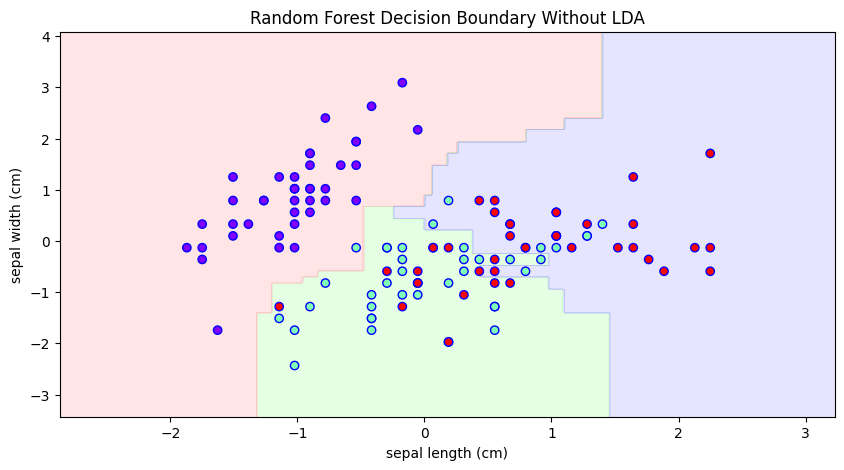

In [6]:
X_train_2D = X_train[:, :2]

rf_without_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_without_lda.fit(X_train_2D, Y_train)

x_min, x_max = X_train_2D[:,0].min() - 1, X_train_2D[:,0].max() + 1
y_min, y_max = X_train_2D[:,1].min() - 1, X_train_2D[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

Z = rf_without_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

plt.figure(figsize=(10, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2D[:,0], X_train_2D[:,1], c=Y_train, cmap='rainbow', edgecolors='b')

plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Random Forest Decision Boundary Without LDA')

plt.show()

### <br>6. Applying LDA

We reduce the feature space to 2 components to maximize class separability:

- **`LinearDiscriminantAnalysis(n_components=2)`** reduces features to 2 components
- **`.fit_transform(X_train, Y_train)`** fits LDA on training data and transforms it
- **`.transform(X_test)`** projects test data onto the same LDA components

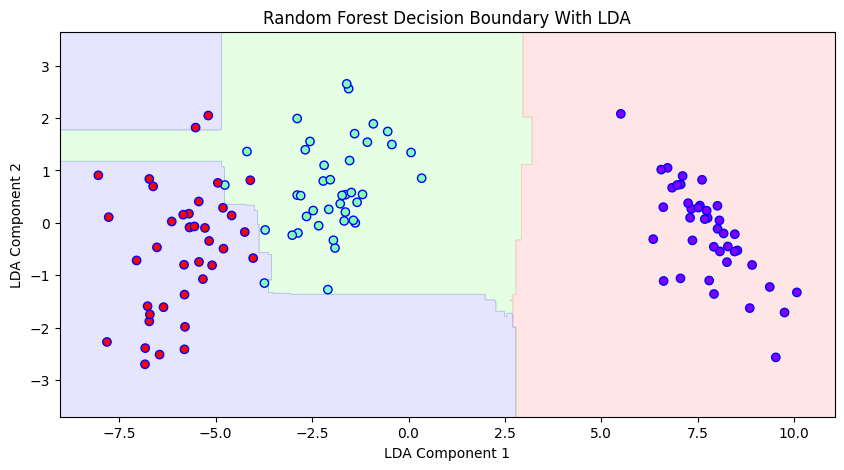

In [7]:
lda = LinearDiscriminantAnalysis(n_components=2)

X_train_lda = lda.fit_transform(X_train, Y_train)
X_test_lda = lda.transform(X_test)

rf_with_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_with_lda.fit(X_train_lda, Y_train)

x_min, x_max = X_train_lda[:,0].min() - 1, X_train_lda[:,0].max() + 1
y_min, y_max = X_train_lda[:,1].min() - 1, X_train_lda[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = rf_with_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=Y_train, cmap='rainbow', edgecolors='b')

plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('Random Forest Decision Boundary With LDA')

plt.show()

## Advantages of LDA

- Simple and computationally efficient.
- Works well even when the number of features is much larger than the number of training samples.
- Can handle multicollinearity.

## Disadvantages of LDA

- Assumes Gaussian distribution of data which may not always be the case.
- Assumes equal covariance matrices for different classes which may not hold in all datasets.
- Assumes linear separability which is not always true.
- May not always perform well in high-dimensional feature spaces.

## Applications of LDA

**Face Recognition:** It is used to reduce the high-dimensional feature space of pixel values in face recognition applications helping to identify faces more efficiently.

**Medical Diagnosis:** It classifies disease severity in mild, moderate or severe based on patient parameters helping in decision-making for treatment.

**Customer Identification:** It can help identify customer segments most likely to purchase a specific product based on survey data.